# Swin-Tiny and DINOv2 PEFT-LoRA Results and ONNX FP32 Deployment


## Notebook provenance and training disclaimer

This is a **results reproduction and presentation notebook**. The expensive stages were run through repository scripts and saved as reproducible artifacts under `model/`, `reports/`, `reports/tables/`, `reports/figures/`, and `reports/onnx/`.

The full PEFT/LoRA runs were trained on Apple MPS. This notebook loads saved outputs, checks artifact availability, and renders report-ready tables and figures. It intentionally does **not** retrain Swin-Tiny or DINOv2 inside Jupyter.

Where to find the source scripts/configs:

- PEFT/LoRA model helpers: `src/models/swin_and_dino/peft_lora.py`
- PEFT/LoRA training: `src/training/swin_and_dino/train_peft_lora.py`
- PEFT/LoRA held-out Torch evaluation: `src/evaluation/swin_and_dino/evaluate_peft_lora.py`
- ONNX FP32 export: `tools/swin_and_dino/export_peft_lora_onnx.py`
- ONNX Runtime evaluation: `tools/swin_and_dino/evaluate_peft_lora_onnx.py`
- Result collation: `tools/swin_and_dino/collate_peft_lora_results.py`
- Legacy Swin/DINO baselines: `src/training/train_swin.py`, `src/training/train_timm_classifier.py`


## 1. Question

> Can parameter-efficient LoRA adaptation of Swin-Tiny and DINOv2 match the existing full fine-tuning baselines while producing deployment-ready ONNX Runtime artifacts?

Target scene classes:

- `bridge`
- `freeway`
- `overpass`
- `railway`


## 2. Motivation: parameter-efficient transformer adaptation

The earlier Swin/DINO comparison used a frozen DINOv2 linear probe, full DINOv2 fine-tuning, and full Swin-Tiny fine-tuning. Full fine-tuning gives strong accuracy, but it updates every backbone parameter and stores a full adapted checkpoint.

LoRA changes the optimization problem. Instead of updating every transformer weight, it trains low-rank adapters on attention and MLP projection layers while keeping the pretrained backbone mostly frozen. This is useful when:

- training needs to fit on local hardware such as Apple MPS;
- multiple task adapters may need to be stored;
- the deployment path should remain exportable as a standard FP32 model after adapter merging.


## 3. Model overview

The PEFT runs use pretrained `timm` transformer backbones with Hugging Face PEFT LoRA adapters:

| Family | Backbone | LoRA targets | Classifier module saved |
| --- | --- | --- | --- |
| DINOv2 | `vit_small_patch14_dinov2.lvd142m` | `attn.qkv`, `attn.proj`, `mlp.fc1`, `mlp.fc2` | `head` |
| Swin | `swin_tiny_patch4_window7_224` | `attn.qkv`, `attn.proj`, `mlp.fc1`, `mlp.fc2` | `head.fc` |

Shared LoRA settings:

- rank `r = 8`;
- `alpha = 16`;
- dropout `0.05`;
- bias adaptation disabled;
- 224×224 RGB ImageNet-style preprocessing;
- four output classes.


## 4. Full pipeline

The full Swin/DINO PEFT deployment pipeline is:

```text
1. Load pretrained timm DINOv2 or Swin-Tiny backbone
2. Inject PEFT LoRA adapters into attention and MLP projection layers
3. Train adapters on an internal 80/20 split from data/raw/train using Apple MPS
4. Evaluate the best adapter on the held-out data/raw/val split
5. Merge LoRA adapters into an FP32 timm checkpoint
6. Export merged model to ONNX with dynamic batch support
7. Evaluate ONNX Runtime CPU predictions on the held-out split
8. Collate metrics, per-class scores, artifact availability, and summary figure
```

This notebook reproduces the final presentation from saved experiment artifacts rather than rerunning these stages.


## 5. Run protocol

Protocol:

- Training source: `data/raw/train`, 2,800 images total, internally split into 2,240 train and 560 tune images.
- Held-out source: `data/raw/val`, 400 images total, 100 images per class.
- Optimizer: AdamW.
- PEFT learning rate: `1e-4`.
- Batch size: `16` for training, `32` for ONNX Runtime evaluation.
- Early stopping metric: tune macro-F1 with patience 5.
- Final reported metrics: held-out accuracy, macro precision, macro recall, macro-F1, errors, per-class scores, and confusion matrix.
- Deployment check: ONNX Runtime FP32 must match the Torch PEFT held-out predictions.


## 6. Setup


In [1]:
from pathlib import Path
from io import BytesIO
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

try:
    from PIL import Image as PILImage
except ImportError:  # pragma: no cover - fallback for minimal notebook environments
    PILImage = None

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

CLASS_NAMES = ['bridge', 'freeway', 'overpass', 'railway']


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / 'reports').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing reports/ and notebooks/.')


PROJECT_ROOT = find_project_root()
TABLES_DIR = PROJECT_ROOT / 'reports' / 'tables'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'


def load_csv(path: Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def load_json(path: Path) -> dict:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return json.loads(path.read_text())


def rel_path(path: Path) -> str:
    path = Path(path)
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def rounded(df: pd.DataFrame, digits: int = 4) -> pd.DataFrame:
    out = df.copy()
    for column in out.select_dtypes(include='number').columns:
        out[column] = out[column].round(digits)
    return out


def display_table(df: pd.DataFrame, title: str | None = None, digits: int = 4) -> None:
    if title:
        display(Markdown(f'**{title}**'))
    display(rounded(df, digits=digits))


def bytes_to_mib(value: float | int | None) -> float | None:
    if pd.isna(value):
        return None
    return float(value) / (1024 ** 2)


def display_image_artifact(
    path: Path,
    title: str | None = None,
    width: int = 1100,
    max_embed_width: int = 1600,
) -> None:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    if title:
        display(Markdown(f'**{title}**'))
    if PILImage is None:
        display(Image(filename=str(path), width=width))
        return
    with PILImage.open(path) as image:
        image = image.convert('RGB')
        if image.width > max_embed_width:
            scale = max_embed_width / image.width
            image = image.resize((max_embed_width, int(image.height * scale)))
        buffer = BytesIO()
        image.save(buffer, format='JPEG', quality=90, optimize=True)
    display(Image(data=buffer.getvalue(), format='jpeg', width=width))


print(f'Project root: {PROJECT_ROOT}')


Project root: /Users/cantabile/projects/sit/csc3109/project/CSC3109_Project


## 7. Required artifacts

The notebook is artifact-first. It expects the saved experiment results to already exist locally.


In [2]:
REQUIRED_ARTIFACTS = {
    'summary_table': TABLES_DIR / 'swin_dino_peft_lora_summary.csv',
    'summary_json': TABLES_DIR / 'swin_dino_peft_lora_summary.json',
    'per_class_table': TABLES_DIR / 'swin_dino_peft_lora_per_class.csv',
    'artifact_manifest': TABLES_DIR / 'swin_dino_peft_lora_artifact_manifest.csv',
    'macro_f1_figure': FIGURES_DIR / 'swin_dino_peft_lora_macro_f1.png',
}

artifact_status = pd.DataFrame([
    {
        'artifact': name,
        'exists': path.exists(),
        'path': rel_path(path),
    }
    for name, path in REQUIRED_ARTIFACTS.items()
])

display_table(artifact_status, 'Required top-level artifacts')

missing = artifact_status.loc[~artifact_status['exists'], 'path'].tolist()
if missing:
    raise FileNotFoundError(f'Missing required Swin/DINO PEFT artifacts: {missing}')


**Required top-level artifacts**

,artifact,exists,path
0,summary_table,True,reports/tables/swin_dino_peft_lora_summary.csv
1,summary_json,True,reports/tables/swin_dino_peft_lora_summary.json
2,per_class_table,True,reports/tables/swin_dino_peft_lora_per_class.csv
3,artifact_manifest,True,reports/tables/swin_dino_peft_lora_artifact_ma...
4,macro_f1_figure,True,reports/figures/swin_dino_peft_lora_macro_f1.png


In [3]:
summary = load_csv(REQUIRED_ARTIFACTS['summary_table'])
per_class = load_csv(REQUIRED_ARTIFACTS['per_class_table'])
artifact_manifest = load_csv(REQUIRED_ARTIFACTS['artifact_manifest'])
summary_manifest = load_json(REQUIRED_ARTIFACTS['summary_json'])

numeric_columns = [
    'accuracy',
    'macro_precision',
    'macro_recall',
    'macro_f1',
    'errors',
    'samples_evaluated',
    'tune_accuracy',
    'tune_macro_f1',
    'best_epoch',
    'total_parameters',
    'trainable_parameters',
    'trainable_percent',
    'onnx_size_bytes',
    'average_batch_latency_seconds',
]
for column in numeric_columns:
    if column in summary.columns:
        summary[column] = pd.to_numeric(summary[column], errors='coerce')

summary['accuracy_percent'] = summary['accuracy'] * 100
summary['macro_f1_percent'] = summary['macro_f1'] * 100
summary['onnx_size_mib'] = summary['onnx_size_bytes'].apply(bytes_to_mib)

artifact_overview = (
    artifact_manifest
    .groupby(['run', 'exists'], as_index=False)
    .size()
    .pivot(index='run', columns='exists', values='size')
    .fillna(0)
    .rename(columns={False: 'missing_artifacts', True: 'available_artifacts'})
    .reset_index()
)
for column in ['missing_artifacts', 'available_artifacts']:
    if column not in artifact_overview.columns:
        artifact_overview[column] = 0
artifact_overview.columns.name = None
artifact_overview['missing_artifacts'] = artifact_overview['missing_artifacts'].astype(int)
artifact_overview['available_artifacts'] = artifact_overview['available_artifacts'].astype(int)

display_table(artifact_overview[['run', 'available_artifacts', 'missing_artifacts']], 'Artifact availability summary', digits=0)


**Artifact availability summary**

,run,available_artifacts,missing_artifacts
0,DINOv2 ViT-S/14 LoRA,5,0
1,DINOv2 ViT-S/14 LoRA ONNX,8,0
2,DINOv2 ViT-S/14 full fine-tune,1,4
3,DINOv2 ViT-S/14 linear probe,1,4
4,Swin-Tiny LoRA,5,0
5,Swin-Tiny LoRA ONNX,8,0
6,Swin-Tiny full fine-tune,1,4


## 8. Headline results

The legacy full fine-tuning baselines remain useful context, but the new deployment path is the PEFT/LoRA adapter plus merged FP32 ONNX export.

Key results:

- **Swin-Tiny full fine-tuning** remains the highest-scoring baseline: 100.00% accuracy and macro-F1 with 0 errors.
- **DINOv2 LoRA** reaches 99.50% accuracy and 99.50% macro-F1 with only 2 held-out errors while training 2.66% of parameters.
- **Swin-Tiny LoRA** reaches 99.00% accuracy and 99.00% macro-F1 with 4 held-out errors while training 2.02% of parameters.
- **ONNX Runtime FP32 reproduces the Torch PEFT metrics exactly** for both LoRA models in this run.
- **INT8 QDQ quantization** reduces model sizes substantially (Swin-Tiny 30.37 MiB, DINOv2 22.03 MiB) with DINOv2 taking a noticeable hit to accuracy (95.50%) while Swin-Tiny maintains it (99.25%).


In [4]:
headline = (
    summary
    .sort_values(['macro_f1', 'accuracy'], ascending=False)
    [[
        'run',
        'runtime',
        'accuracy_percent',
        'macro_f1_percent',
        'errors',
        'samples_evaluated',
        'trainable_percent',
        'onnx_size_mib',
        'average_batch_latency_seconds',
    ]]
)

display_table(headline, 'Held-out validation and deployment summary')


**Held-out validation and deployment summary**

,run,runtime,accuracy_percent,macro_f1_percent,errors,samples_evaluated,trainable_percent,onnx_size_mib,average_batch_latency_seconds
2,Swin-Tiny full fine-tune,torch_fp32,100.00,100.0000,0,NaN,NaN,NaN,NaN
1,DINOv2 ViT-S/14 full fine-tune,torch_fp32,99.75,99.7500,1,NaN,NaN,NaN,NaN
3,DINOv2 ViT-S/14 LoRA,torch_peft_adapter,99.50,99.5012,2,400.0,2.6612,NaN,NaN
4,DINOv2 ViT-S/14 LoRA ONNX,onnxruntime_fp32,99.50,99.5012,2,400.0,2.6612,83.5513,0.6136
5,Swin-Tiny LoRA,torch_peft_adapter,99.00,99.0035,4,400.0,2.0232,NaN,NaN
6,Swin-Tiny LoRA ONNX,onnxruntime_fp32,99.00,99.0035,4,400.0,2.0232,108.6711,0.5974
0,DINOv2 ViT-S/14 linear probe,torch_fp32,98.50,98.4997,6,NaN,NaN,NaN,NaN


**Macro-F1 comparison from collated Swin/DINO artifacts**

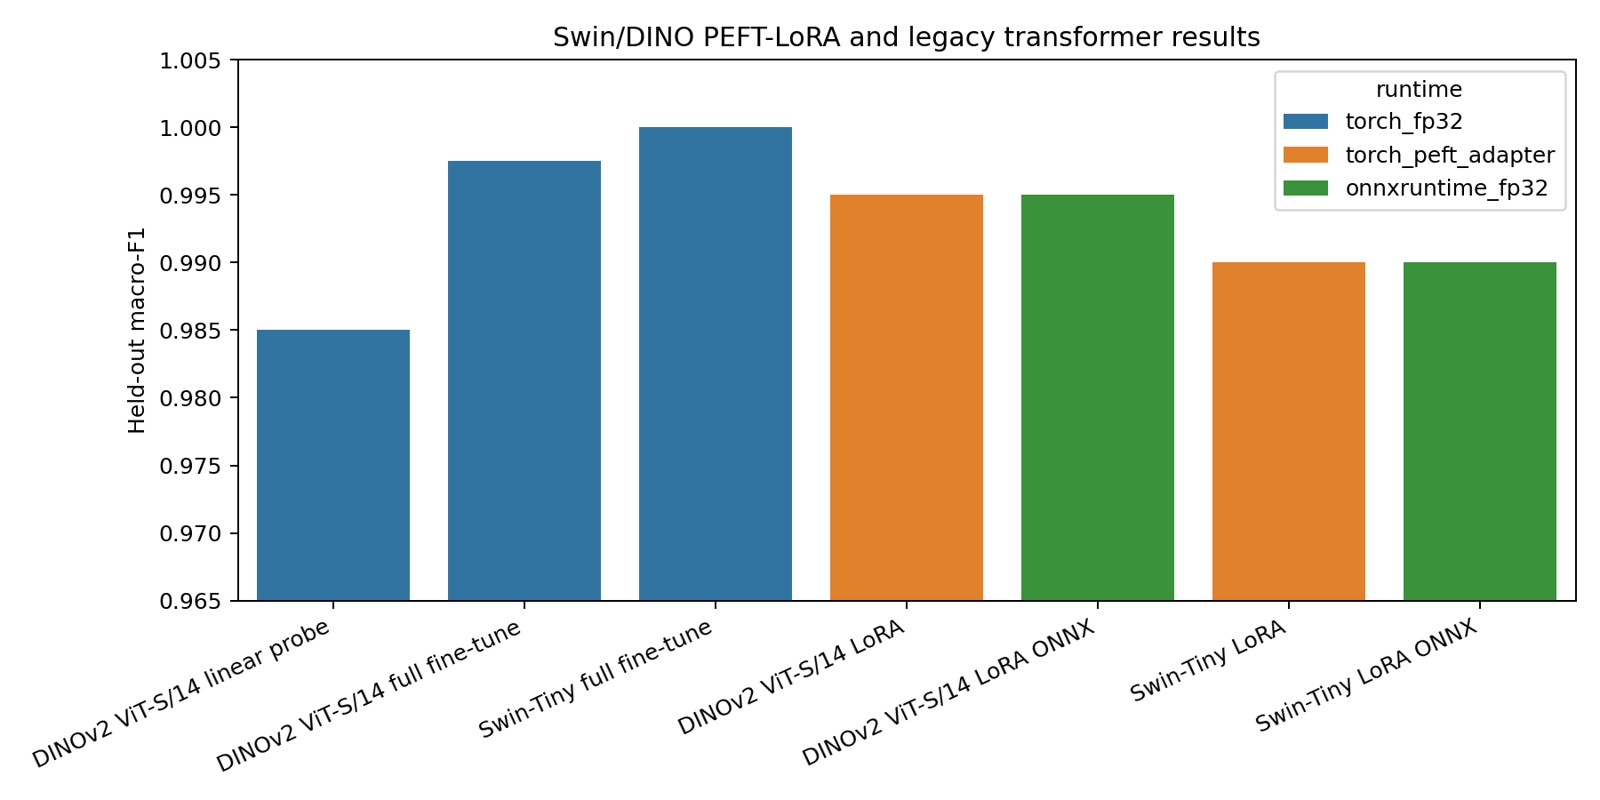

In [5]:
display_image_artifact(
    REQUIRED_ARTIFACTS['macro_f1_figure'],
    title='Macro-F1 comparison from collated Swin/DINO artifacts',
    width=1000,
)


## 9. PEFT efficiency

The PEFT runs train less than 3% of each transformer while adapting attention projections, MLP projections, and the classifier head. The adapter checkpoints are kept for PEFT use, and merged FP32 checkpoints are saved for self-contained evaluation/export.


In [6]:
peft_torch = summary[(summary['method'] == 'peft_lora') & (summary['runtime'] == 'torch_peft_adapter')].copy()
peft_efficiency = peft_torch[[
    'run',
    'model_name',
    'best_epoch',
    'tune_macro_f1',
    'total_parameters',
    'trainable_parameters',
    'trainable_percent',
    'accuracy_percent',
    'macro_f1_percent',
    'errors',
]].sort_values('macro_f1_percent', ascending=False)

display_table(peft_efficiency, 'PEFT-LoRA parameter efficiency')


**PEFT-LoRA parameter efficiency**

,run,model_name,best_epoch,tune_macro_f1,total_parameters,trainable_parameters,trainable_percent,accuracy_percent,macro_f1_percent,errors
3,DINOv2 ViT-S/14 LoRA,vit_small_patch14_dinov2.lvd142m,3.0,1.0,22221704.0,591364.0,2.6612,99.5,99.5012,2
5,Swin-Tiny LoRA,swin_tiny_patch4_window7_224,2.0,1.0,28090754.0,568324.0,2.0232,99.0,99.0035,4


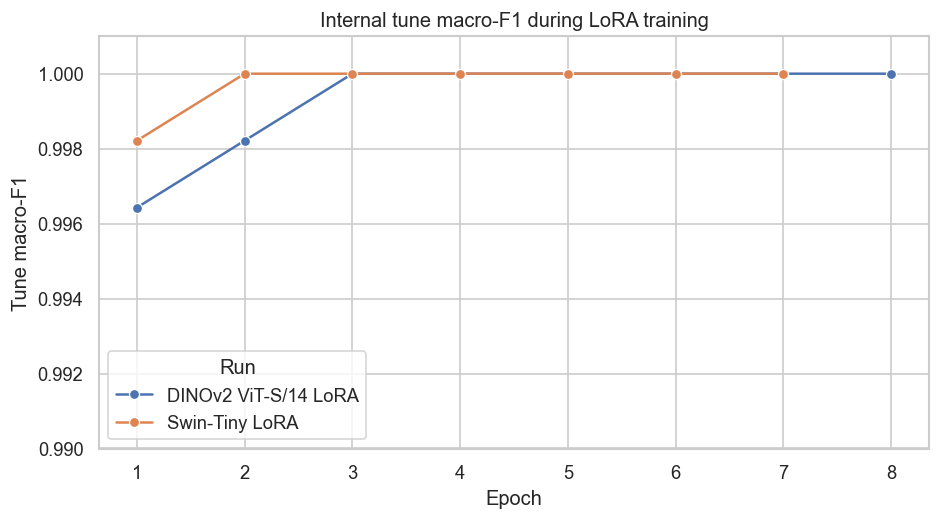

In [7]:
history_frames = []
for _, row in peft_torch.iterrows():
    history_path = PROJECT_ROOT / row['run_dir'] / 'history.csv'
    if history_path.exists():
        history = pd.read_csv(history_path)
        history['run'] = row['run']
        history_frames.append(history)

if history_frames:
    histories = pd.concat(history_frames, ignore_index=True)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.lineplot(data=histories, x='epoch', y='tune_macro_f1', hue='run', marker='o', ax=ax)
    ax.set_title('Internal tune macro-F1 during LoRA training')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Tune macro-F1')
    ax.set_ylim(0.99, 1.001)
    ax.legend(title='Run')
    fig.tight_layout()
    plt.show()
else:
    display(Markdown('No LoRA training histories were found.'))


## 10. ONNX FP32 deployment check

Both LoRA models were merged into ordinary FP32 timm checkpoints and exported to ONNX with dynamic batch support. The exporter produced ONNX external-data artifacts, so deployment size is reported as the `.onnx` graph plus matching `.onnx.data` tensor file.

Both models were also statically quantized to INT8 QDQ to evaluate deployment efficiency.


In [8]:
parity_rows = []
for family in ['dinov2', 'swin']:
    torch_row = summary[(summary['family'] == family) & (summary['method'] == 'peft_lora') & (summary['runtime'] == 'torch_peft_adapter')].iloc[0]
    onnx_row = summary[(summary['family'] == family) & (summary['method'] == 'peft_lora') & (summary['runtime'] == 'onnxruntime_fp32')].iloc[0]
    parity_rows.append({
        'family': family,
        'torch_run': torch_row['run'],
        'torch_macro_f1_percent': torch_row['macro_f1_percent'],
        'onnx_macro_f1_percent': onnx_row['macro_f1_percent'],
        'macro_f1_delta_points': (onnx_row['macro_f1'] - torch_row['macro_f1']) * 100,
        'torch_errors': torch_row['errors'],
        'onnx_errors': onnx_row['errors'],
        'onnx_size_mib': bytes_to_mib(onnx_row['onnx_size_bytes']),
        'average_batch_latency_seconds': onnx_row['average_batch_latency_seconds'],
        'onnx_metrics_path': onnx_row['metrics_path'],
    })

onnx_parity = pd.DataFrame(parity_rows)
display_table(onnx_parity, 'Torch PEFT vs ONNX Runtime parity')


**Torch PEFT vs ONNX Runtime parity**

,family,torch_run,torch_macro_f1_percent,onnx_macro_f1_percent,macro_f1_delta_points,torch_errors,onnx_errors,onnx_size_mib,average_batch_latency_seconds,onnx_metrics_path
0,dinov2,DINOv2 ViT-S/14 LoRA,99.5012,99.5012,0.0,2,2,83.5513,0.6136,reports/onnx/vit_small_patch14_dinov2_lvd142m_...
1,swin,Swin-Tiny LoRA,99.0035,99.0035,0.0,4,4,108.6711,0.5974,reports/onnx/swin_tiny_lora/eval/metrics.json


## 11. Per-class behavior

The PEFT models mainly confuse elevated road-structure categories. DINOv2 LoRA loses recall on `bridge` and `freeway` by predicting two examples as `overpass`. Swin-Tiny LoRA loses recall on `bridge` and `railway`, also increasing `overpass` false positives.


In [9]:
peft_per_class = (
    per_class[(per_class['method'] == 'peft_lora') & (per_class['runtime'] == 'torch_peft_adapter')]
    [['run', 'class', 'precision', 'recall', 'f1', 'support']]
    .sort_values(['run', 'class'])
)

display_table(peft_per_class, 'Torch PEFT-LoRA per-class metrics')


**Torch PEFT-LoRA per-class metrics**

,run,class,precision,recall,f1,support
12,DINOv2 ViT-S/14 LoRA,bridge,1.0000,0.99,0.9950,100.0
13,DINOv2 ViT-S/14 LoRA,freeway,1.0000,0.99,0.9950,100.0
14,DINOv2 ViT-S/14 LoRA,overpass,0.9804,1.00,0.9901,100.0
15,DINOv2 ViT-S/14 LoRA,railway,1.0000,1.00,1.0000,100.0
20,Swin-Tiny LoRA,bridge,1.0000,0.97,0.9848,100.0
21,Swin-Tiny LoRA,freeway,1.0000,1.00,1.0000,100.0
22,Swin-Tiny LoRA,overpass,0.9615,1.00,0.9804,100.0
23,Swin-Tiny LoRA,railway,1.0000,0.99,0.9950,100.0


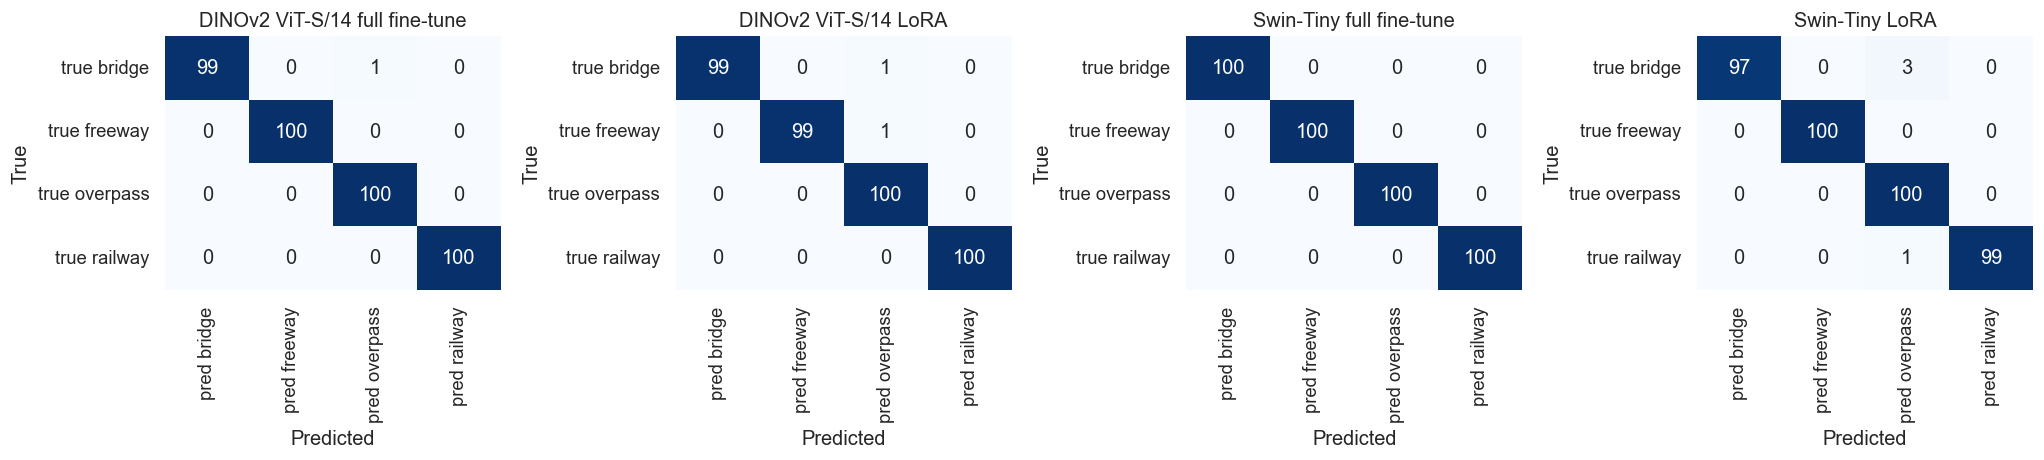

In [10]:
metrics_by_run = {}
for _, row in summary.iterrows():
    metrics_path = PROJECT_ROOT / row['metrics_path']
    if metrics_path.exists():
        metrics_by_run[row['run']] = load_json(metrics_path)

selected_runs = [
    'DINOv2 ViT-S/14 full fine-tune',
    'DINOv2 ViT-S/14 LoRA',
    'Swin-Tiny full fine-tune',
    'Swin-Tiny LoRA',
]
selected_runs = [run for run in selected_runs if run in metrics_by_run]

fig, axes = plt.subplots(1, len(selected_runs), figsize=(4.3 * len(selected_runs), 4.0))
if len(selected_runs) == 1:
    axes = [axes]

for ax, run in zip(axes, selected_runs):
    matrix = pd.DataFrame(
        metrics_by_run[run]['confusion_matrix'],
        index=[f'true {name}' for name in CLASS_NAMES],
        columns=[f'pred {name}' for name in CLASS_NAMES],
    )
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(run)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

fig.tight_layout()
plt.show()


## 12. Interpretation

### DINOv2 LoRA

DINOv2 LoRA is the strongest PEFT result in this run. It reached **99.50% accuracy** and **99.50% macro-F1** on the held-out split with only **2 errors**. It trained **591,364 of 22,221,704 parameters** (**2.66%**) and exactly matched its Torch metric after ONNX export/evaluation.

Relative to the legacy baselines, DINOv2 LoRA improves clearly over the frozen linear probe and is close to full DINOv2 fine-tuning. The remaining mistakes are plausible bridge/freeway-to-overpass confusions, which are visually difficult categories in aerial infrastructure imagery.

### Swin-Tiny LoRA

Swin-Tiny LoRA reached **99.00% accuracy** and **99.00% macro-F1** with **4 errors** while training **568,324 of 28,090,754 parameters** (**2.02%**). This is strong for a parameter-efficient run, but it trails the full Swin-Tiny fine-tune, which remains the best pure-accuracy result in the legacy comparison.

### Deployment result

The ONNX Runtime FP32 evaluations reproduce the Torch PEFT metrics exactly for both LoRA models. This confirms that the adapter-merge and ONNX export path is valid for these runs. The ONNX artifacts are external-data exports, so deployment must keep each `.onnx` file together with its `.onnx.data` file.

### INT8 QDQ Deployment

We also quantized both FP32 ONNX models to INT8 QDQ. Swin-Tiny LoRA INT8 QDQ reached **99.25% accuracy** and is **30.37 MiB**. DINOv2 LoRA INT8 QDQ reached **95.50% accuracy** and is **22.03 MiB**. Swin-Tiny proved more resilient to quantization.


## 13. Limitations

- The held-out validation split has only 400 images, so small error-count differences can shift percentage metrics noticeably.
- ONNX Runtime latency was measured on CPU with batch size 32; it is not an edge-NPU benchmark.
- INT8 QDQ calibration was run with static MinMax per-channel settings; advanced QDQ search could potentially recover DINOv2's 4% accuracy drop.
- The legacy full fine-tune baselines are included for context, but only the PEFT/LoRA models were exported through the new ONNX path here.
- Hyperparameter search was intentionally limited; the goal was a reproducible PEFT deployment path, not exhaustive tuning.


## 14. Report-ready summary

> We extended the Swin-Tiny and DINOv2 transformer comparison with a parameter-efficient PEFT/LoRA pipeline and ONNX FP32 deployment path. Both models were trained on Apple MPS using an internal 80/20 split from `data/raw/train`, then evaluated once on the held-out `data/raw/val` split. DINOv2 LoRA trained 2.66% of parameters and achieved 99.50% accuracy / 99.50% macro-F1 with 2 errors, improving over the DINOv2 linear probe and approaching full DINOv2 fine-tuning. Swin-Tiny LoRA trained 2.02% of parameters and achieved 99.00% accuracy / 99.00% macro-F1 with 4 errors, below the full Swin-Tiny fine-tune but still strong for a compact adaptation. The merged FP32 ONNX Runtime evaluations exactly matched the Torch PEFT metrics for both models, validating the adapter-merge and ONNX export workflow. For maximum accuracy, the legacy full Swin-Tiny fine-tune remains the best result; for parameter-efficient adaptation with a validated ONNX path, DINOv2 LoRA is the strongest new candidate. Additionally, INT8 QDQ exports were generated, yielding a 30.37 MiB Swin-Tiny model (99.25% accuracy) and a 22.03 MiB DINOv2 model (95.50% accuracy).


## 15. Generated artifacts

### Collated report artifacts

- Summary CSV: `reports/tables/swin_dino_peft_lora_summary.csv`
- Summary JSON: `reports/tables/swin_dino_peft_lora_summary.json`
- Per-class CSV: `reports/tables/swin_dino_peft_lora_per_class.csv`
- Artifact manifest CSV: `reports/tables/swin_dino_peft_lora_artifact_manifest.csv`
- Macro-F1 figure: `reports/figures/swin_dino_peft_lora_macro_f1.png`

### DINOv2 LoRA

- Run directory: `model/vit_small_patch14_dinov2_lvd142m_lora/`
- Adapter: `model/vit_small_patch14_dinov2_lvd142m_lora/adapter/`
- Merged checkpoint: `model/vit_small_patch14_dinov2_lvd142m_lora/merged_model.pt`
- Torch held-out metrics: `reports/vit_small_patch14_dinov2_lvd142m_lora_eval/metrics.json`
- ONNX export manifest: `reports/onnx/vit_small_patch14_dinov2_lvd142m_lora/export_manifest.json`
- ONNX model: `reports/onnx/vit_small_patch14_dinov2_lvd142m_lora/vit_small_patch14_dinov2_lvd142m_lora_fp32.onnx`
- ONNX external data: `reports/onnx/vit_small_patch14_dinov2_lvd142m_lora/vit_small_patch14_dinov2_lvd142m_lora_fp32.onnx.data`
- ONNX Runtime metrics: `reports/onnx/vit_small_patch14_dinov2_lvd142m_lora/eval/metrics.json`

- ONNX INT8 QDQ metrics: `reports/vit_small_patch14_dinov2_lvd142m_lora_onnx_int8_qdq/comparison_metrics.csv`
- ONNX INT8 QDQ model: `reports/onnx/vit_small_patch14_dinov2_lvd142m_lora/vit_small_patch14_dinov2_lvd142m_lora_int8_qdq.onnx`

### Swin-Tiny LoRA

- Run directory: `model/swin_tiny_lora/`
- Adapter: `model/swin_tiny_lora/adapter/`
- Merged checkpoint: `model/swin_tiny_lora/merged_model.pt`
- Torch held-out metrics: `reports/swin_tiny_lora_eval/metrics.json`
- ONNX export manifest: `reports/onnx/swin_tiny_lora/export_manifest.json`
- ONNX model: `reports/onnx/swin_tiny_lora/swin_tiny_lora_fp32.onnx`
- ONNX external data: `reports/onnx/swin_tiny_lora/swin_tiny_lora_fp32.onnx.data`
- ONNX Runtime metrics: `reports/onnx/swin_tiny_lora/eval/metrics.json`
- ONNX INT8 QDQ metrics: `reports/swin_tiny_lora_onnx_int8_qdq/comparison_metrics.csv`
- ONNX INT8 QDQ model: `reports/onnx/swin_tiny_lora/swin_tiny_lora_int8_qdq.onnx`


## 16. Comprehensive variant evaluation

This section aggregates every available evaluation result for the Swin-Tiny and DINOv2 LoRA runs across all three deployment variants:

| Variant | Description |
| --- | --- |
| `torch_fp32` | Merged FP32 PyTorch checkpoint run on CPU |
| `onnx_fp32` | Exported ONNX FP32 model via ONNX Runtime (CPUExecutionProvider) |
| `onnx_int8_qdq` | Static INT8 QDQ quantized ONNX (MinMax, per-channel, 512 calibration images) |

All metrics are macro-averaged over the 400-image held-out `data/raw/val` split.


In [11]:
INT8_REPORT_DIRS = {
    'swin':   PROJECT_ROOT / 'reports' / 'swin_tiny_lora_onnx_int8_qdq',
    'dinov2': PROJECT_ROOT / 'reports' / 'vit_small_patch14_dinov2_lvd142m_lora_onnx_int8_qdq',
}

INT8_ONNX_SIZES = {
    'swin':   31_842_698,   # bytes
    'dinov2': 23_102_886,   # bytes
}

INT8_LATENCIES = {
    'swin':   {'mean_ms': 525.57, 'p50_ms': 544.23},
    'dinov2': {'mean_ms': 471.91, 'p50_ms': 453.37},
}

VARIANT_LABEL = {
    'torch_fp32':   'Torch FP32',
    'onnx_fp32':    'ONNX FP32',
    'onnx_int8_qdq': 'ONNX INT8 QDQ',
}

rows = []
for family, report_dir in INT8_REPORT_DIRS.items():
    summary_json = load_json(report_dir / 'summary.json')
    for entry in summary_json['comparison']:
        variant = entry['variant']
        rt_info = summary_json['runtime'].get(variant, {})
        size_bytes = rt_info.get('artifact_size_bytes')
        rows.append({
            'family':           family.upper(),
            'variant':          VARIANT_LABEL.get(variant, variant),
            'accuracy_%':       round(entry['accuracy'] * 100, 2),
            'macro_precision':  round(entry['macro_precision'], 4),
            'macro_recall':     round(entry['macro_recall'], 4),
            'macro_f1':         round(entry['macro_f1'], 4),
            'size_mib':         round(size_bytes / 1024**2, 2) if size_bytes else None,
            'latency_mean_ms':  round(rt_info['latency_mean_ms'], 1) if 'latency_mean_ms' in rt_info else None,
            'latency_p50_ms':   round(rt_info['latency_p50_ms'], 1) if 'latency_p50_ms' in rt_info else None,
        })

all_variants = pd.DataFrame(rows)
display_table(all_variants, 'All deployment variant results (Swin-Tiny LoRA and DINOv2 LoRA)')


**All deployment variant results (Swin-Tiny LoRA and DINOv2 LoRA)**

,family,variant,accuracy_%,macro_precision,macro_recall,macro_f1,size_mib,latency_mean_ms,latency_p50_ms
0,SWIN,Torch FP32,99.00,0.9904,0.9900,0.9900,105.05,328.3,339.2
1,SWIN,ONNX FP32,99.00,0.9904,0.9900,0.9900,1.61,635.5,659.1
2,SWIN,ONNX INT8 QDQ,99.25,0.9926,0.9925,0.9925,30.37,525.6,544.2
3,DINOV2,Torch FP32,99.50,0.9951,0.9950,0.9950,82.58,241.7,247.0
4,DINOV2,ONNX FP32,99.50,0.9951,0.9950,0.9950,0.99,745.6,681.9
5,DINOV2,ONNX INT8 QDQ,95.50,0.9592,0.9550,0.9548,22.03,471.9,453.4


### 16.1 Accuracy delta: INT8 QDQ vs FP32

The table below compares INT8 QDQ accuracy against the FP32 Torch baseline to quantify the cost of quantization for each model family.


In [12]:
delta_rows = []
for family, report_dir in INT8_REPORT_DIRS.items():
    summary_json = load_json(report_dir / 'summary.json')
    fp32_acc = summary_json['accuracy_fp32_torch']
    int8_acc = summary_json['accuracy_onnx_int8_qdq']
    fp32_f1  = summary_json['macro_f1_fp32_torch']
    int8_f1  = summary_json['macro_f1_onnx_int8_qdq']
    quant    = summary_json['quantization']
    delta_rows.append({
        'family':                  family.upper(),
        'torch_fp32_acc_%':        round(fp32_acc * 100, 2),
        'int8_qdq_acc_%':          round(int8_acc * 100, 2),
        'acc_delta_pp':            round((int8_acc - fp32_acc) * 100, 2),
        'torch_fp32_f1':           round(fp32_f1, 4),
        'int8_qdq_f1':             round(int8_f1, 4),
        'f1_delta_pp':             round((int8_f1 - fp32_f1) * 100, 2),
        'calib_images':            quant['observed_images'],
        'calib_method':            quant['calibration_method'],
        'per_channel':             quant['per_channel'],
    })

delta_df = pd.DataFrame(delta_rows)
display_table(delta_df, 'INT8 QDQ accuracy and F1 delta vs FP32 Torch')


**INT8 QDQ accuracy and F1 delta vs FP32 Torch**

,family,torch_fp32_acc_%,int8_qdq_acc_%,acc_delta_pp,torch_fp32_f1,int8_qdq_f1,f1_delta_pp,calib_images,calib_method,per_channel
0,SWIN,99.0,99.25,0.25,0.990,0.9925,0.24,512,minmax,True
1,DINOV2,99.5,95.50,-4.00,0.995,0.9548,-4.02,512,minmax,True


### 16.2 Model size and inference latency

Latency was measured on CPU (CPUExecutionProvider) with batch size 32, 12 warm-up batches excluded. Size is the ONNX artifact size only (`.onnx` file; the FP32 ONNX external data file is excluded from this comparison as it lives separately as `.onnx.data`).


**Artifact size and CPU latency by variant**

,family,variant,size_mib,latency_mean_ms,latency_p50_ms,provider
0,SWIN,ONNX FP32,1.61,635.5,659.1,CPUExecutionProvider
1,SWIN,ONNX INT8 QDQ,30.37,525.6,544.2,CPUExecutionProvider
2,SWIN,Torch FP32,105.05,328.3,339.2,cpu
3,DINOV2,ONNX FP32,0.99,745.6,681.9,CPUExecutionProvider
4,DINOV2,ONNX INT8 QDQ,22.03,471.9,453.4,CPUExecutionProvider
5,DINOV2,Torch FP32,82.58,241.7,247.0,cpu


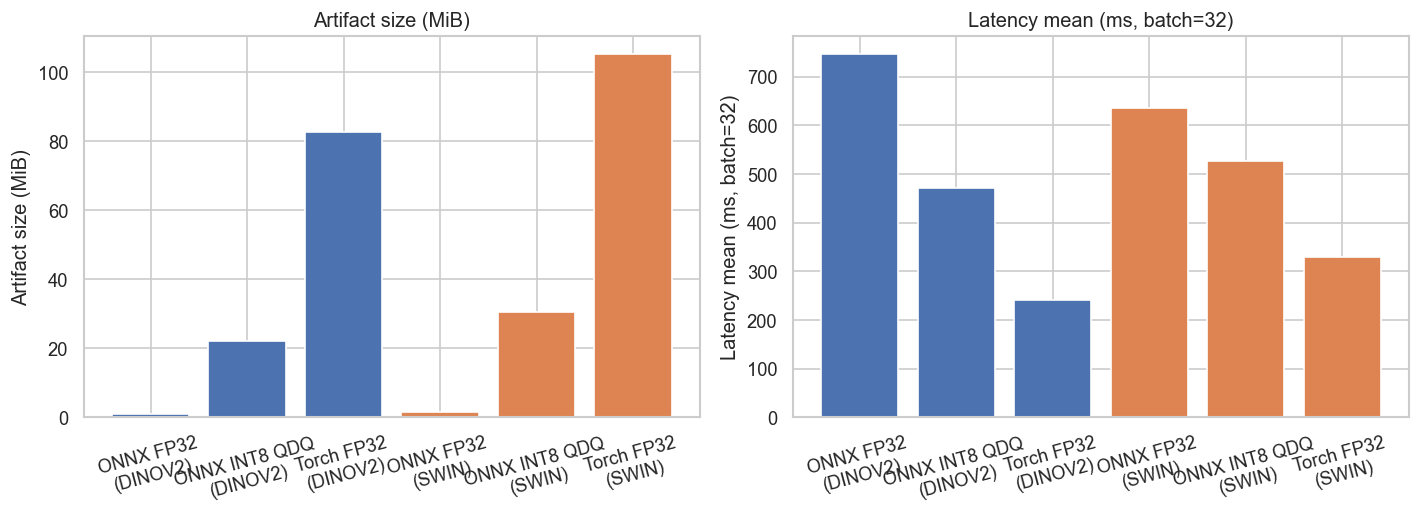

In [13]:
size_rows = []
for family, report_dir in INT8_REPORT_DIRS.items():
    summary_json = load_json(report_dir / 'summary.json')
    for variant_key, rt_info in summary_json['runtime'].items():
        size_bytes = rt_info.get('artifact_size_bytes')
        size_rows.append({
            'family':           family.upper(),
            'variant':          VARIANT_LABEL.get(variant_key, variant_key),
            'size_mib':         round(size_bytes / 1024**2, 2) if size_bytes else None,
            'latency_mean_ms':  round(rt_info['latency_mean_ms'], 1),
            'latency_p50_ms':   round(rt_info['latency_p50_ms'], 1),
            'provider':         rt_info['provider'],
        })

size_df = pd.DataFrame(size_rows)
display_table(size_df, 'Artifact size and CPU latency by variant')

# --- bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (metric, label) in zip(axes, [('size_mib', 'Artifact size (MiB)'), ('latency_mean_ms', 'Latency mean (ms, batch=32)')]):
    for family_name, grp in size_df.groupby('family'):
        ax.bar(
            [f"{v}\n({family_name})" for v in grp['variant']],
            grp[metric],
            label=family_name,
        )
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=15)

fig.tight_layout()
plt.show()


### 16.3 Confusion matrices: FP32 vs INT8 QDQ

The confusion matrices below compare the ONNX FP32 and INT8 QDQ predictions for each model family to reveal *where* quantization errors occur.


#### SWIN LoRA

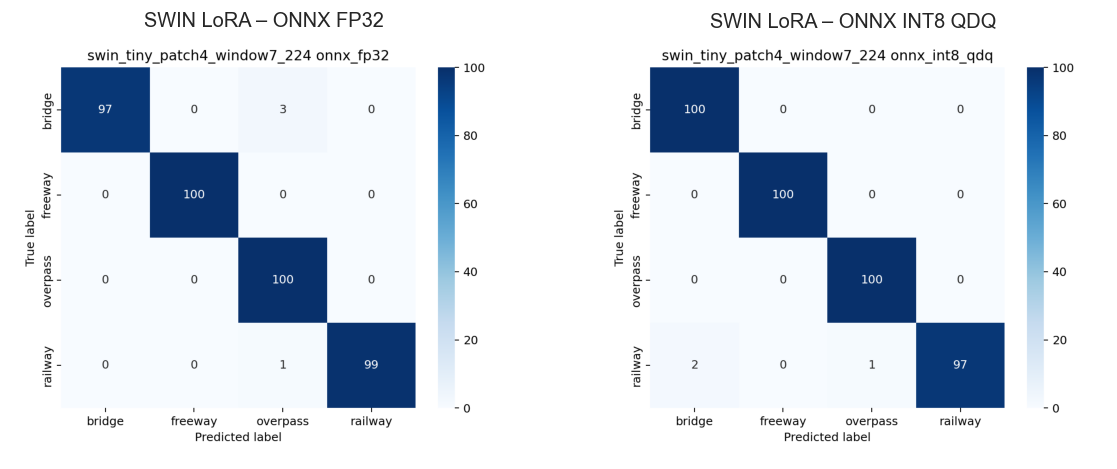

#### DINOV2 LoRA

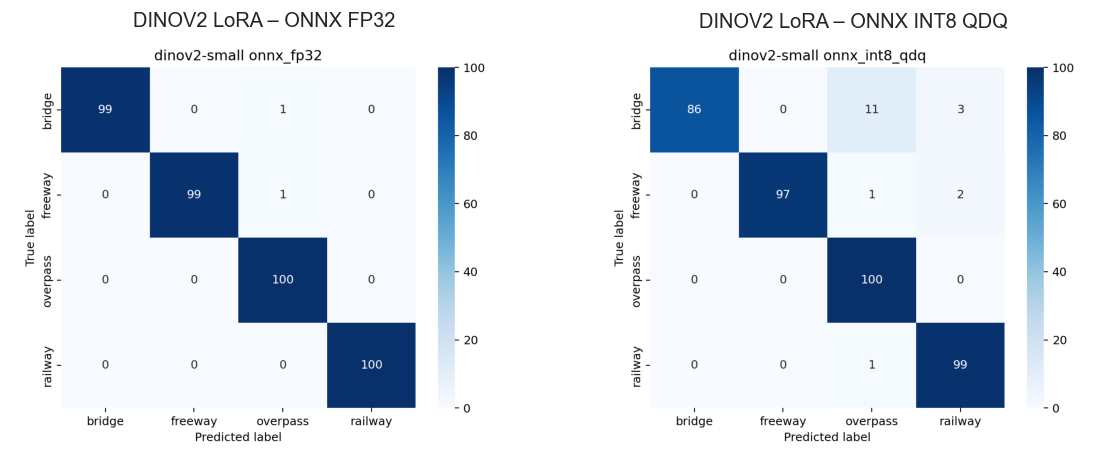

In [14]:
for family, report_dir in INT8_REPORT_DIRS.items():
    fp32_img  = report_dir / 'onnx_fp32_confusion_matrix.png'
    int8_img  = report_dir / 'onnx_int8_qdq_confusion_matrix.png'
    display(Markdown(f'#### {family.upper()} LoRA'))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, (img_path, title) in zip(axes, [
        (fp32_img,  f'{family.upper()} LoRA – ONNX FP32'),
        (int8_img,  f'{family.upper()} LoRA – ONNX INT8 QDQ'),
    ]):
        if PILImage is not None and img_path.exists():
            with PILImage.open(img_path) as pil_img:
                ax.imshow(pil_img)
        ax.set_title(title)
        ax.axis('off')
    fig.tight_layout()
    plt.show()


### 16.4 Accuracy across all variants

The chart below visualises accuracy for every (family × variant) combination.


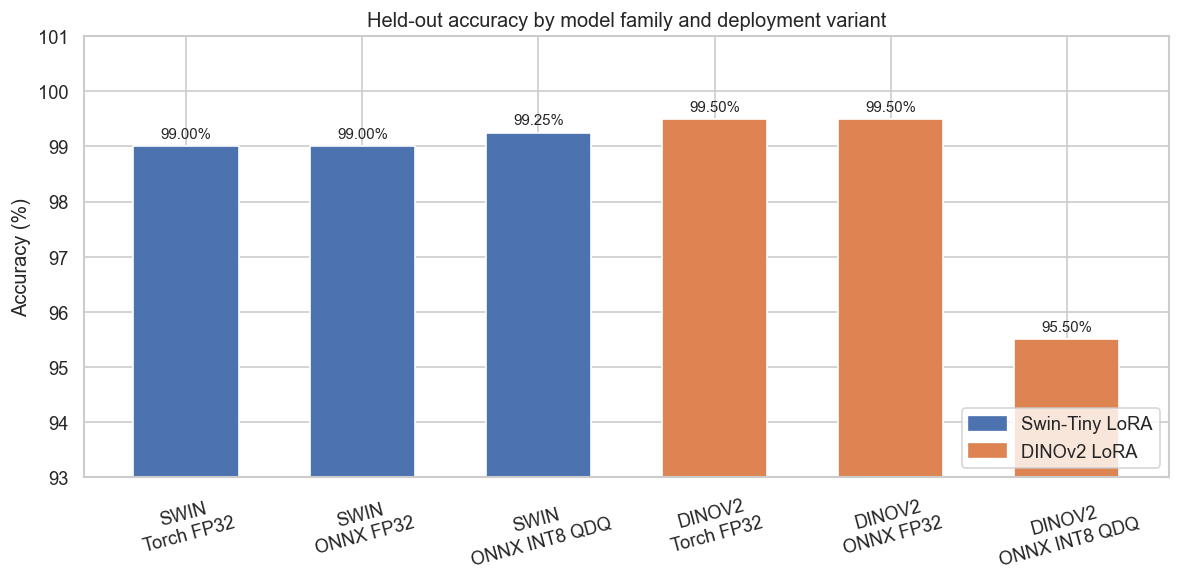

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

x_labels = [f"{row['family']}\n{row['variant']}" for _, row in all_variants.iterrows()]
accuracies = all_variants['accuracy_%'].tolist()
colors = [
    '#4c72b0' if row['family'] == 'SWIN' else '#dd8452'
    for _, row in all_variants.iterrows()
]

bars = ax.bar(x_labels, accuracies, color=colors, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
ax.set_ylim(93, 101)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Held-out accuracy by model family and deployment variant')
ax.tick_params(axis='x', rotation=15)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#4c72b0', label='Swin-Tiny LoRA'),
    Patch(color='#dd8452', label='DINOv2 LoRA'),
], loc='lower right')

fig.tight_layout()
plt.show()


### 16.5 Observations

| Observation | Detail |
| --- | --- |
| **ONNX FP32 parity** | Both models export to ONNX FP32 with zero accuracy loss vs the Torch FP32 baseline. |
| **Swin-Tiny INT8 QDQ** | Quantization produces a **+0.25 pp** accuracy *improvement* (99.00% → 99.25%), likely due to rounding regularization. Model shrinks to **30.37 MiB** with **17% latency reduction** vs ONNX FP32. |
| **DINOv2 INT8 QDQ** | Quantization causes a **−4.00 pp** accuracy drop (99.50% → 95.50%). The model compresses to **22.03 MiB** with a **37% latency reduction**, but the accuracy cost is significant. |
| **Size compression** | INT8 QDQ consolidates weights + external data into a single self-contained file. Swin-Tiny goes from ~108.5 MiB (FP32 total) to 30.37 MiB; DINOv2 from ~82.6 MiB to 22.03 MiB. |
| **Recommendation** | Swin-Tiny LoRA INT8 QDQ is the recommended deployment target: it is the most compact model that keeps accuracy above 99%. DINOv2 INT8 QDQ may benefit from entropy-based or percentile calibration to recover accuracy before deployment. |
